# Aprendizaje de Máquina

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Chunga, Juan Miguel (juanmiguel.ch2014@gmail.com)
- Gonzalez, Juan (juan.gonzalez.working@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Carga del dataset

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import entropy
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [3]:
body_fat_dataset = pd.read_csv("./dataset/bodyfat.csv")

In [4]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Descripción general del dataset

Para este trabajo final se seleccionó el [Body Fat Prediction](https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset) dataset de la plataforma [Kaggle](https://www.kaggle.com/).

Este dataset se caracteriza por tener información correspondiente a las mediciones del porcentaje de grasa corporal de distintas personas, presentada en 252 registros con 15 columnas.

Las columnas son las siguientes:

| Columna | Descripción |
| --- | --- |
| Density | Densidad, determinada a partir del pesaje debajo del agua |
| BodyFat | Porcentaje de grasa corporal, acorde a la [ecuación de Siri](https://www.sciencedirect.com/science/article/pii/S1279770723024442) |
| Age | Edad, medida en años |
| Weight | Peso, en libras |
| Height | Altura, en pulgadas |
| Neck | Circunferencia del cuello, medida en centímetros |
| Chest | Circunferencia del pecho, en centímetros |
| Abdomen | Circunferencia del abdomen, en centímetros |
| Hip | Circunferencia de la cintura, en centímetros |
| Thigh | Circunferencia del muslo, en centímetros |
| Knee | Circunferencia de la rodilla, en centímetros |
| Ankle | Circunferencia del tobillo, en centímetros |
| Bicep | Circunferencia del bicep (extendido), en centímetros |
| Forearm | Circunferencia del antebrazo, en centímetros |
| Wrist | Circunferencia de la muñeca, en centímetros |

## Descripción del problema a resolver

El objetivo de este trabajo práctico consiste en la resolución de un problema de regresión sobre el `Body fat prediction` dataset, más precisamente, sobre la variable `BodyFat`.

***TO-DO***: describir qué se realizará en el trabajo (modelos a explorar, comparaciones entre modelos? con que profundidad/nivel de detalle?).

## Paso 1 - Análisis exploratorio del dataset

### Paso 1.1 - Análisis de columnas del dataset

Comenzamos analizando la dimensión del dataset, la cual se observa que es de $252$ filas por $15$ columnas.

In [5]:
body_fat_dataset.shape

(252, 15)

En la siguiente celda se muestran las primeras 5 filas del dataset, para tener una primera visión de las mismas.

In [6]:
body_fat_dataset.head(5)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


Mostramos mediante el método `describe` algunas características de cada columna, tales como la cantidad total (*count*), media (*mean*), desvío estandar (*std*), valores mínimos y máximos (*min* y *max*), y los percentiles *25%*, *50%* y *75%*.

In [7]:
body_fat_dataset.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


A continuación se definen una serie de funciones que nos permitirán analizar ciertas métricas de cada columna:

In [8]:
# Devuelve métricas relacionadas al rango Intercuartil
def metricas_iqr(data):
    Q1 = data.quantile(0.25)
    Q2 = data.quantile(0.50)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1
    min_iqr = Q1 - 1.5*IQR
    max_iqr = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_iqr, max_iqr

In [9]:
# Devuelve varias métricas de una columna
def obtener_metricas_columna(dataset, col):
    data = dataset[col]

    skewness = data.skew()
    kurtosis = data.kurt()
    media = data.mean()
    moda = data.mode()[0]
    mediana = data.median()
    var = data.std()
    min = data.min()
    max = data.max()
    nunique = data.nunique()
    mask_cant_ceros = data == 0
    cant_ceros = len(dataset[mask_cant_ceros])

    Q1, _, Q3, IQR, min_iqr, max_iqr = metricas_iqr(data)

    return media, moda, mediana, var, min, max, nunique, cant_ceros, Q1, Q3, IQR, min_iqr, max_iqr, skewness, kurtosis

In [10]:
def mostrar_metricas_dataset(dataset):
    print(f"\tColumna\t|\tMedia\t\t\t|\tModa\t|\tMediana\t|\tVarianza\t\t|\tMínimo\t|\tMáximo\t|\tCant. Únicos\t|\tCant. ceros\t|\tSkewness\t\t|\tKurtosis\t\t|")
    for col in dataset.columns:
        media, moda, mediana, var, min, max, nunique, cant_ceros, _, _, _, _, _, skewness, kurtosis = obtener_metricas_columna(dataset=dataset, col=col)

        print(f"\t{col}\t|\t{media}\t|\t{moda}\t|\t{mediana}\t|\t{var}\t|\t{min}\t|\t{max}\t|\t{nunique}\t\t|\t{cant_ceros}\t\t|\t{skewness}\t|\t{kurtosis}\t|")

En la siguiente tabla se pueden observar otras métricas que se calcularon sobre cada columna, tales como:

- Cant. únicos: muestra la cantidad de valores únicos en cada columna. Se recuerda que hay 252 registros totales.
- Cant. ceros: muestra la cantidad de registros con valor cero en cada columna. En todo el dataset hay un solo cero, y corresponde a un registro con `BodyFat` cero.
- `Skewness`: indica si la distribución de una variable presenta asimetría o no.
    - Un valor positivo indica asimetría a derecha.
    - Un valor negativo indica asimetría a izquierda.
    - Se calcula con la función [Skew](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html) de pandas.
- `Kurtosis`: describe la forma de una distribución de una variable, en particular, su cola o su pico en relación con una distribución Normal.
    - Se calcula con la función [kurt](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.kurt.html#pandas-dataframe-kurt) de pandas, la cual usa la definición de Fisher (kurtosis de una Normal = 0).
    - Un valor positivo indica una distribución con colas más pesadas y un pico más pronunciado que una Normal (leptocúrtica). En algunos casos, las colas pesadas pueden indicar presencia de outliers.
    - Un valor negativo indica una distribución con colas más ligeras y una forma más plana que una Normal (platicúrtica).

| Columna	|	Media			|	Moda	|	Mediana	|	Varianza		|	Mínimo	|	Máximo	|	Cant. Únicos	|	Cant. ceros	|	Skewness		|	Kurtosis		|
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Density	|	1.0555738095238094	|	1.061	|	1.0549	|	0.019031434171520773	|	0.995	|	1.1089	|	218		|	0		|	-0.020175732162877553	|	-0.3096191237706498	|
| BodyFat	|	19.150793650793652	|	20.4	|	19.2	|	8.368740413029707	|	0.0	|	47.5	|	176		|	1		|	0.14635310763344916	|	-0.3338113932133209	|
| Age	|	44.88492063492063	|	40	|	43.0	|	12.602039722717864	|	22	|	81	|	51		|	0		|	0.2835210972594456	|	-0.4164409142706198	|
| Weight	|	178.92440476190475	|	152.25	|	176.5	|	29.38915988536906	|	118.5	|	363.15	|	197		|	0		|	1.205262933190293	|	5.269513616992537	|
| Height	|	70.14880952380952	|	71.5	|	70.0	|	3.6628557876803174	|	29.5	|	77.75	|	48		|	0		|	-5.384986543608024	|	59.54430208610579	|
| Neck	|	37.992063492063494	|	38.5	|	38.0	|	2.430913234019508	|	31.1	|	51.2	|	90		|	0		|	0.5526199393706229	|	2.7196150888425112	|
| Chest	|	100.82420634920635	|	99.1	|	99.65	|	8.43047553192002	|	79.3	|	136.2	|	174		|	0		|	0.6815557089086869	|	0.9872822206849676	|
| Abdomen	|	92.55595238095238	|	88.7	|	90.95	|	10.783076801381705	|	69.4	|	148.1	|	185		|	0		|	0.838417893390718	|	2.2488237551253754	|
| Hip	|	99.9047619047619	|	98.3	|	99.3	|	7.164057666842289	|	85.0	|	147.7	|	152		|	0		|	1.4971273119966988	|	7.4713521085780314	|
| Thigh	|	59.405952380952385	|	58.9	|	59.0	|	5.249952028401044	|	47.2	|	87.3	|	139		|	0		|	0.8212095695704776	|	2.665714462785864	|
| Knee	|	38.59047619047619	|	39.0	|	38.5	|	2.411804587018756	|	33.0	|	49.1	|	90		|	0		|	0.5167439948759139	|	1.0615358688338015	|
| Ankle	|	23.10238095238095	|	22.0	|	22.8	|	1.6948933981786372	|	19.1	|	33.9	|	61		|	0		|	2.255134289967066	|	11.945194424674785	|
| Biceps	|	32.2734126984127	|	30.5	|	32.05	|	3.0212737512508645	|	24.8	|	45.0	|	104		|	0		|	0.28552999037686816	|	0.49849833584912107	|
| Forearm	|	28.663888888888895	|	27.3	|	28.7	|	2.0206911650269284	|	21.0	|	34.9	|	77		|	0		|	-0.21933277506022672	|	0.8663094115243686	|
| Wrist	|	18.229761904761904	|	18.8	|	18.3	|	0.9335849289587035	|	15.8	|	21.4	|	44		|	0		|	0.28161390690959204	|	0.39567752094226005	|

In [11]:
mostrar_metricas_dataset(body_fat_dataset)

	Columna	|	Media			|	Moda	|	Mediana	|	Varianza		|	Mínimo	|	Máximo	|	Cant. Únicos	|	Cant. ceros	|	Skewness		|	Kurtosis		|
	Density	|	1.0555738095238094	|	1.061	|	1.0549	|	0.019031434171520773	|	0.995	|	1.1089	|	218		|	0		|	-0.020175732162877553	|	-0.3096191237706498	|
	BodyFat	|	19.150793650793652	|	20.4	|	19.2	|	8.368740413029707	|	0.0	|	47.5	|	176		|	1		|	0.14635310763344916	|	-0.3338113932133209	|
	Age	|	44.88492063492063	|	40	|	43.0	|	12.602039722717864	|	22	|	81	|	51		|	0		|	0.2835210972594456	|	-0.4164409142706198	|
	Weight	|	178.92440476190475	|	152.25	|	176.5	|	29.38915988536906	|	118.5	|	363.15	|	197		|	0		|	1.205262933190293	|	5.269513616992537	|
	Height	|	70.14880952380952	|	71.5	|	70.0	|	3.6628557876803174	|	29.5	|	77.75	|	48		|	0		|	-5.384986543608024	|	59.54430208610579	|
	Neck	|	37.992063492063494	|	38.5	|	38.0	|	2.430913234019508	|	31.1	|	51.2	|	90		|	0		|	0.5526199393706229	|	2.7196150888425112	|
	Chest	|	100.82420634920635	|	99.1	|	99.65	|	8.43047553192002	|	79.3	|	136

A continuación se grafican los histogramas correspondientes a las variables del dataset.

In [12]:
def plot_histogramas(data, columns, figsize=(5,5), kde=True, ncols=3, colores = ["gray", "blue", "red"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, col in enumerate(columns):
        sns.histplot(data[col], kde=kde, ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])
    
    plt.tight_layout()
    plt.show()

    return

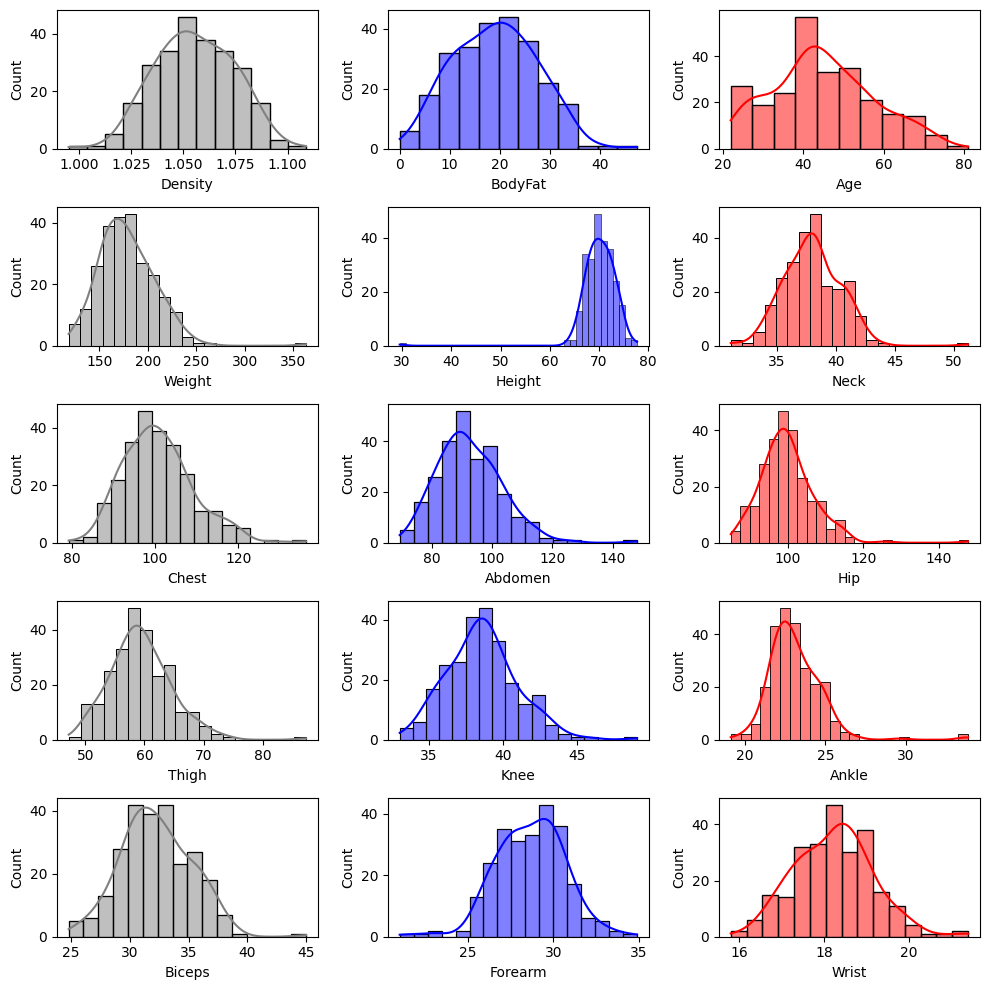

In [13]:
plot_histogramas(body_fat_dataset, body_fat_dataset.columns, figsize=(10,10))

En alguno de estos gráficos se puede observar características calculadas sobre las variables.

Por ejemplo, las variables `Height`, `Hip` y `Ankle` tienen colas pesadas, lo cual se debe a su valores calculados de *Kurtosis* ($59.5$, $7.47$ y $11.9$ respectivamente).
También se observan asimetrías, tal como indican los valores de Skewness. Por ejemplo, `Height` tiene un valor de $-5.38$, lo cual explica su asimetría a izquierda.

### Paso 1.2 - Análisis de nulos

En esta sección se procede a realizar un análisis de datos faltantes.

Su tratamiento se realizará en secciones posteriores, una vez realizado el split del dataset en *train* y *test*.

Mediante el método `info` obtenemos otras características de las columnas, tales como la cantidad de datos no nulos (*Non-null count*) y el tipo de dato (*Dtype*).

Se observa lo siguiente:

- Ninguna columna tiene valores nulos.
- Todas las columnas son numéricas continuas (*float64*), a excepción de la columna `Age` (edad), que es numérica discreta (*int64*).

In [14]:
body_fat_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


Si bien el método `info` indica que no hay datos nulos, validamos esto de la siguiente manera:

In [15]:
body_fat_dataset.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

Si bien pandas se encarga de tratar los *Null*/*None* como *NaN* (más info [aquí](https://medium.com/@allenhuang1996/whats-the-difference-between-null-and-nan-in-python-a1af20d523ce)), se procede a hacer el análisis de la siguiente manera:

In [16]:
body_fat_dataset.isna().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

Como el dataset contiene información correspondiente a distintas mediciones, también consideraremos nulos a aquellos registros que tengan columnas con valores ceros.

A continuación, se observa el único registro con columnas con valores ceros. En este caso corresponde al registro número 181, y el valor en cero es la columna `BodyFat`.

In [17]:
for col in body_fat_dataset.columns:
    mascara = body_fat_dataset[col] == 0
    data_ceros = body_fat_dataset[mascara]
    cant_ceros = len(data_ceros)

    if cant_ceros > 0:
        print(data_ceros)

     Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  \
181   1.1089      0.0   40   118.5    68.0  33.8   79.3     69.4  85.0   47.2   

     Knee  Ankle  Biceps  Forearm  Wrist  
181  33.5   20.2    27.7     24.6   16.5  


La conclusión de esta sección dedicada al análisis de nulos es que el dataset prácticamente no tiene valores faltantes, a excepción de un solo registro con valor de `BodyFat` en cero.

El tratamiento de este registro se realizará en secciones posteriores, luego de realizar el split en *train* y *test*.

### Paso 1.3 - Análisis de outliers

En esta sección se realizará un análisis de outliers para el dataset de `Body Fat prediction`.

En caso de encontrar outliers, se tratará a estos una vez realizado el split del dataset original en *train* y *test*.

In [18]:
def calcular_cantidad_outliers(dataset, col):
    data = dataset[col]
    Q1, Q2, Q3, IQR, min_iqr, max_iqr = metricas_iqr(data)

    mascara_min_iqr = data < min_iqr
    mascara_max_iqr = data > max_iqr

    cant_outliers_izq = len(dataset[mascara_min_iqr])
    cant_outliers_der = len(dataset[mascara_max_iqr])
    total_outliers = cant_outliers_izq + cant_outliers_der

    return total_outliers, cant_outliers_izq, cant_outliers_der, Q1, Q2, Q3, IQR, min_iqr, max_iqr

Se procede a realizar un análisis de outliers de manera cuantitativa, utilizando el rango intercuartil.

El rango intercuartil se define como la diferencia del cuartil tres (75% de los datos) con el cuartil uno (25% de los datos), es decir $IQR = Q3 - Q1$.

Se consideran outliers a:

- Valores menores a $Q1 - 1.5 * IQR$ (los llamaremos outliers a izquierda).
- Valores mayores a $Q3 + 1.5 * IQR$ (los llamaremos outliers a derecha).

En la siguiente tabla se observan los resultados del análisis cuantitativo de outliers para el dataset de `Body Fat prediction`.

La variable con mayor cantidad de outliers es `Forearm`, la cual tiene $5$ outliers.

|	Columna	|Total de outliers|	Outliers a izquierda	|	Outliers a derecha	|	Q1	|	Q3	|	IQR	|	Q1-1.5*IQR	|	Q3+1.5*IQR	|
| --- |--- |--- |--- |--- |--- |--- |--- |--- |
|	Density	|	1	|	1	|	0	|	1.04	|	1.07	|	0.03	|	1.0	|	1.11	|
|	BodyFat	|	1	|	0	|	1	|	12.48	|	25.3	|	12.82	|	-6.76	|	44.54	|
|	Age	|	0	|	0	|	0	|	35.75	|	54.0	|	18.25	|	8.38	|	81.38	|
|	Weight	|	2	|	0	|	2	|	159.0	|	197.0	|	38.0	|	102.0	|	254.0	|
|	Height	|	1	|	1	|	0	|	68.25	|	72.25	|	4.0	|	62.25	|	78.25	|
|	Neck	|	3	|	2	|	1	|	36.4	|	39.42	|	3.02	|	31.86	|	43.96	|
|	Chest	|	2	|	0	|	2	|	94.35	|	105.38	|	11.02	|	77.81	|	121.91	|
|	Abdomen	|	3	|	0	|	3	|	84.57	|	99.32	|	14.75	|	62.45	|	121.45	|
|	Hip	|	3	|	0	|	3	|	95.5	|	103.52	|	8.03	|	83.46	|	115.56	|
|	Thigh	|	4	|	0	|	4	|	56.0	|	62.35	|	6.35	|	46.48	|	71.87	|
|	Knee	|	3	|	0	|	3	|	36.98	|	39.92	|	2.95	|	32.55	|	44.35	|
|	Ankle	|	3	|	0	|	3	|	22.0	|	24.0	|	2.0	|	19.0	|	27.0	|
|	Biceps	|	1	|	0	|	1	|	30.2	|	34.32	|	4.12	|	24.01	|	40.51	|
|	Forearm	|	5	|	4	|	1	|	27.3	|	30.0	|	2.7	|	23.25	|	34.05	|
|	Wrist	|	4	|	1	|	3	|	17.6	|	18.8	|	1.2	|	15.8	|	20.6	|

In [19]:
print("|\tColumna\t|\tTotal de outliers\t|\tOutliers a izquierda\t|\tOutliers a derecha\t|\tQ1\t|\tQ3\t|\tIQR\t|\tQ1-1.5*IQR\t|\tQ3+1.5*IQR\t|")
for col in body_fat_dataset.columns:
    total_outliers, cant_outliers_izq, cant_outliers_der, Q1, Q2, Q3, IQR, min_iqr, max_iqr = calcular_cantidad_outliers(body_fat_dataset, col)

    print(f"|\t{col}\t|\t{total_outliers}\t|\t{cant_outliers_izq}\t|\t{cant_outliers_der}\t|\t{np.round(Q1, 2)}\t|\t{np.round(Q3, 2)}\t|\t{np.round(IQR, 2)}\t|\t{np.round(min_iqr, 2)}\t|\t{np.round(max_iqr, 2)}\t|")


|	Columna	|	Total de outliers	|	Outliers a izquierda	|	Outliers a derecha	|	Q1	|	Q3	|	IQR	|	Q1-1.5*IQR	|	Q3+1.5*IQR	|
|	Density	|	1	|	1	|	0	|	1.04	|	1.07	|	0.03	|	1.0	|	1.11	|
|	BodyFat	|	1	|	0	|	1	|	12.48	|	25.3	|	12.82	|	-6.76	|	44.54	|
|	Age	|	0	|	0	|	0	|	35.75	|	54.0	|	18.25	|	8.38	|	81.38	|
|	Weight	|	2	|	0	|	2	|	159.0	|	197.0	|	38.0	|	102.0	|	254.0	|
|	Height	|	1	|	1	|	0	|	68.25	|	72.25	|	4.0	|	62.25	|	78.25	|
|	Neck	|	3	|	2	|	1	|	36.4	|	39.42	|	3.02	|	31.86	|	43.96	|
|	Chest	|	2	|	0	|	2	|	94.35	|	105.38	|	11.02	|	77.81	|	121.91	|
|	Abdomen	|	3	|	0	|	3	|	84.57	|	99.32	|	14.75	|	62.45	|	121.45	|
|	Hip	|	3	|	0	|	3	|	95.5	|	103.52	|	8.03	|	83.46	|	115.56	|
|	Thigh	|	4	|	0	|	4	|	56.0	|	62.35	|	6.35	|	46.48	|	71.87	|
|	Knee	|	3	|	0	|	3	|	36.98	|	39.92	|	2.95	|	32.55	|	44.35	|
|	Ankle	|	3	|	0	|	3	|	22.0	|	24.0	|	2.0	|	19.0	|	27.0	|
|	Biceps	|	1	|	0	|	1	|	30.2	|	34.32	|	4.12	|	24.01	|	40.51	|
|	Forearm	|	5	|	4	|	1	|	27.3	|	30.0	|	2.7	|	23.25	|	34.05	|
|	Wrist	|	4	|	1	|	3	|	17.6	|	18.8	|

A continuación se crea una función que permite graficar para cada variable un Boxplot.

Esto permite observar gráficamente a los outliers de cada variable.

In [20]:
def plot_boxplot(data, columns, figsize=(5,5), ncols=3, colores = ["gray", "lightblue", "green"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, col in enumerate(columns):
        sns.boxplot(x=data[col], ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])

        axes[math.floor(i/ncols), i%ncols].set_xlabel(col)
        axes[math.floor(i/ncols), i%ncols].set_title(f"Boxplot para {col}")
    
    plt.tight_layout()
    plt.show()

    return

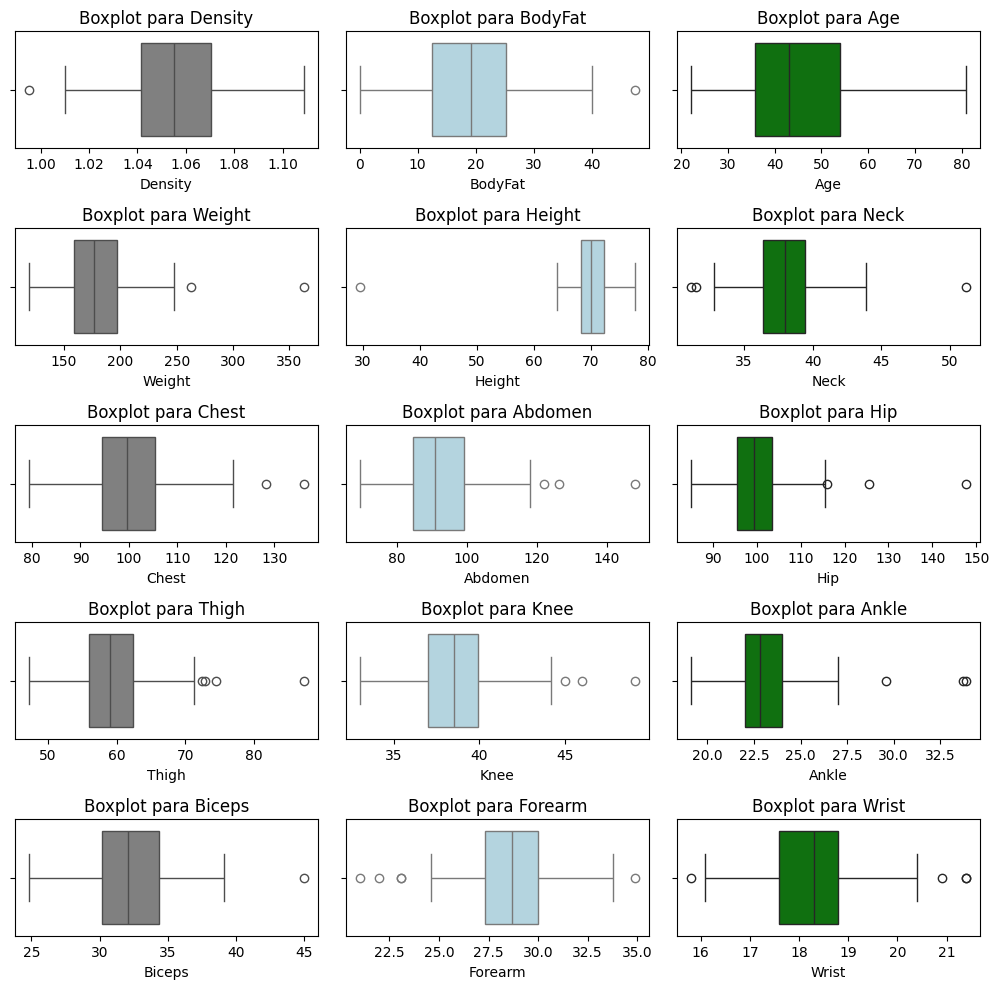

In [21]:
plot_boxplot(body_fat_dataset, body_fat_dataset.columns, figsize=(10,10))

Como conclusión de esta sección podemos decir que, a excepción de `Age`, todas las variables presentan outliers en el dataset.

El tratamiento de estos se realizará en secciones posteriores, una vez se haya realizado el split en *Train* y *Test*.

### Paso 1.4 - Análisis de relación entre variable target y el resto de las variables

A continuación se grafican las variables del dataset contra la variable target `BodyFat`.

In [22]:
def plot_scatterplot(data, columns, ycol, figsize=(5,5), ncols=3, colores = ["gray", "lightblue", "green"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    
    columns = columns.drop(ycol)

    for i, col in enumerate(columns):
        sns.scatterplot(data=data, x=col, y=ycol, ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])

        axes[math.floor(i/ncols), i%ncols].set_xlabel(col)
        axes[math.floor(i/ncols), i%ncols].set_ylabel(ycol)
        axes[math.floor(i/ncols), i%ncols].set_title(f"{ycol} en función de {col}")
    
    plt.tight_layout()
    plt.show()

    return

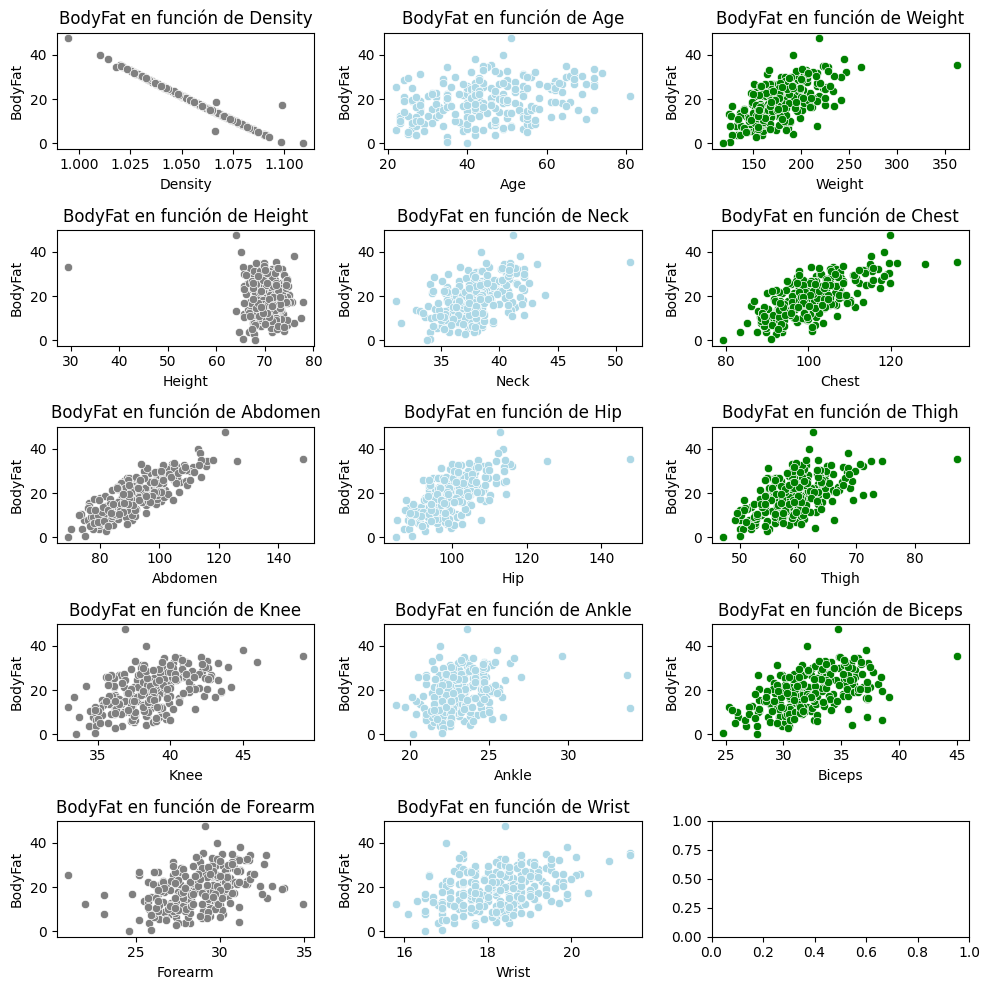

In [23]:
plot_scatterplot(data=body_fat_dataset, columns=body_fat_dataset.columns, ycol="BodyFat", figsize=(10,10))

En el gráfico anterior se puede observar que existe cierta correlación (inversa) entre las variables `BodyFat` y `Density`, lo cual corresponde a lo dicho en la [sección de more details del dataset](https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset).

Otras variables con las que `BodyFat` tiene cierta correlación (por lo que se ve en el gráfico) son:

- `Weight`
- `Abdomen`
- `Chest`
- `Biceps`

Para tener mayor certeza sobre lo dicho anteriormente, se procede a calcular la correlación entre las variables y a realizar un gráfico de las mismas:

In [24]:
# Source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
def plot_correlaciones(data):
    corr = data.corr()

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

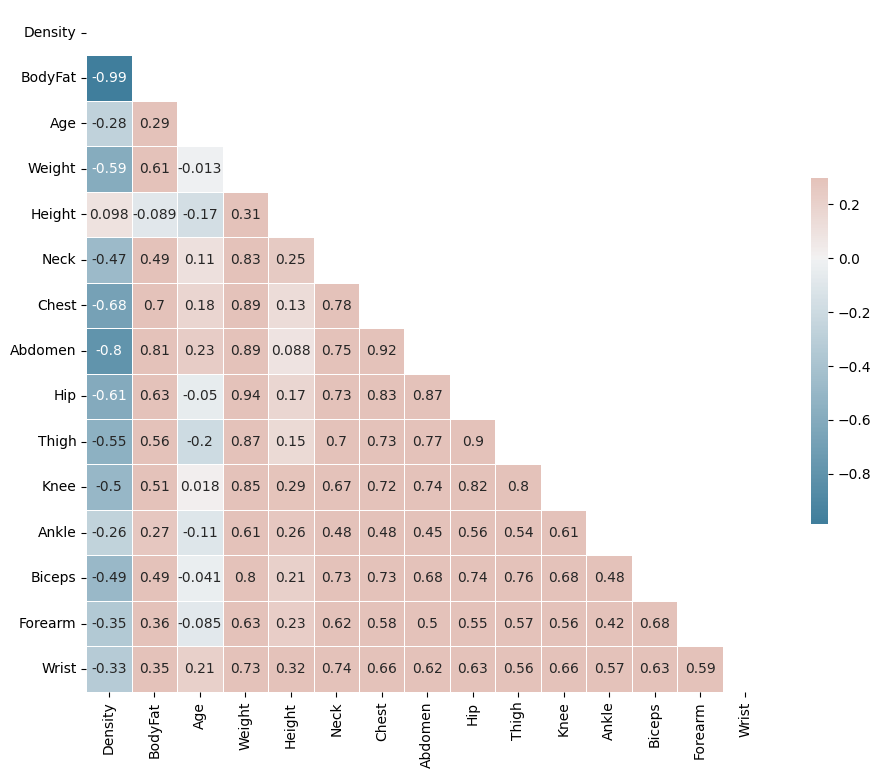

In [25]:
plot_correlaciones(body_fat_dataset)

In [26]:
def obtener_columnas_correlacionadas(dataset, target_col, bounds=[-0.75,0.75]):
    if len(bounds) != 2:
        bounds=[-0.75,0.75]
        print("Atención: `bounds` solo puede tener dos valores. Se sobrescribe con [-0.75,0.75].")

    correlations = dataset.corr()
    corr_target = correlations[target_col]
    mask_upper_bound = corr_target >= bounds[1]
    mask_lower_bound = corr_target <= bounds[0]

    cols_upper_bound = corr_target[mask_upper_bound].index.tolist()
    cols_lower_bound = corr_target[mask_lower_bound].index.tolist()

    return cols_lower_bound, cols_upper_bound

In [27]:
lower, upper = obtener_columnas_correlacionadas(body_fat_dataset, "BodyFat")

print(f"BodyFat: columnas con correlación negativa: {lower}")
print(f"BodyFat: columnas con correlación positiva: {upper}")

BodyFat: columnas con correlación negativa: ['Density']
BodyFat: columnas con correlación positiva: ['BodyFat', 'Abdomen']


Se realizaron un gráfico (heatmap) y un análisis del valor numérico de las correlaciones entre las variables del dataset y `BodyFat`, encontrando que:
- Tiene una correlación negativa con `Density` ($-0.99$)
- Tiene una correlación positiva con `Abdomen` ($0.81$)

Cabe aclarar que se definieron los umbrales de $-0.75$ y $0.75$ para seleccionar las correlaciones de interés.

Los resultados de este análisis serán útiles en pasos posteriores, cuando se busque reducir la dimensionalidad del dataset.

## Paso 2 - Split del dataset

Con el fin de evitar que suceda un [data leakage](https://www.kaggle.com/code/alexisbcook/data-leakage) a la hora de tratar nulos, outliers y realizar operación de *feature engineering* es fundamental realizar un split del dataset en *train* y *test*.

In [28]:
target = "BodyFat"
test_size = 0.3
random_state = 323123

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    body_fat_dataset.drop(columns=target),
    body_fat_dataset[target],
    random_state=random_state,
    test_size=test_size)

In [32]:
X_train.shape

(176, 14)

In [33]:
X_test.shape

(76, 14)

In [34]:
y_train.shape

(176,)

In [35]:
y_test.shape

(76,)

El dataset de *train* quedó conformado por 176 filas y 14 columnas, mientras que el de *test* se conforma de 76 filas y 14 columnas.

## Paso 3 - Tratamiento de nulos

Al realizar un análisis de nulos en el `Paso 1.2` se encontró que hay solamente un registro con valor nulo, más precisamente, un registro con valor de `BodyFat` igual a cero.

El tratamiento de este valor se realizará de la siguiente manera:

1. Dado a que `BodyFat` es la variable target, y a que en el `Paso 2` se la dividió en *train* y *test*, debemos primero localizar en que subconjunto se encuentra este registro.
1. Una vez localizado, se realizarán las siguientes imputaciones:
    1. Imputación por `Media`
    1. Imputación por `Mediana`
    1. Imputación por `Moda`
    1. **NOTA**: estas métricas se obtendrán del dataset de *train*, para evitar data leakage, y se aplicarán sobre el subconjunto correspondiente.
1. Se compararán los resultados de imputaciones, con el fin de seleccionar aquel que menos altere la distribución de la variable target en el subconjunto analizado.
    1. **NOTA**: debido a que se trata de un solo registro a imputar, podemos decir, a priori, que no habrán alteraciones grandes en la distribución de la variable.

### Paso 3.1 - Identificación del registro con valor cero

A continuación se muestra el código necesario para identificar dónde se encuentra el registro a imputar.

Éste está en el subconjunto de *train*.

In [43]:
mask_body_fat_cero_train = y_train == 0.0
mask_body_fat_cero_test = y_test == 0.0

print(f"""Cantidad de registros iguales a cero
    Train:  {len(y_train[mask_body_fat_cero_train])}
    Test:   {len(y_test[mask_body_fat_cero_test])}
    """)

Cantidad de registros iguales a cero
    Train:  1
    Test:   0
    


### Paso 3.2 - Imputación del registro con valor cero

Comenzamos calculando la `media`, `mediana` y `moda` del subconjunto de *train* de la variable *target*.

In [44]:
y_train_mean = y_train.mean()
y_train_median = y_train.median()
y_train_mode = y_train.mode()[0]

Los valores obtenidos son:

- `Media`: $18.662$
- `Mediana`: $18.65$
- `Moda`: $20.4$

In [51]:
print(f"""Body Fat (y_train):
    Media:  {np.round(y_train_mean, 3)}
    Median: {np.round(y_train_median, 3)}
    Mode:   {np.round(y_train_mode, 3)}
""")

Body Fat (y_train):
    Media:  18.662
    Median: 18.65
    Mode:   20.4



Creamos una copia de `y_train` para realizar las imputaciones por separado.

In [54]:
y_train_mean_imputed = y_train.copy().replace(0, y_train_mean)
y_train_median_imputed = y_train.copy().replace(0, y_train_median)
y_train_mode_imputed = y_train.copy().replace(0, y_train_mode)

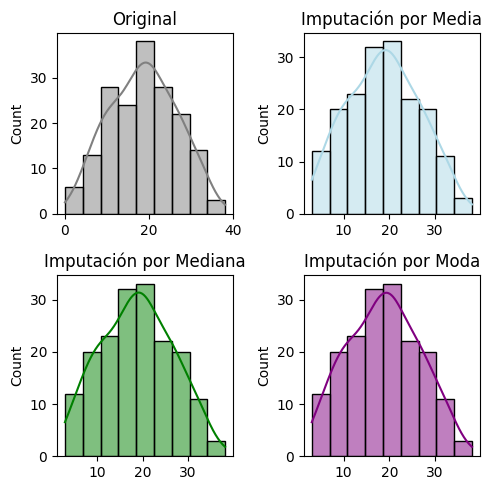

In [56]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5,5))
colores = ["gray", "lightblue", "green", "purple"]
titulos = ["Original", "Imputación por Media", "Imputación por Mediana", "Imputación por Moda"]

sns.histplot(y_train, kde=True, ax=axes[0, 0], color=colores[0])
sns.histplot(y_train_mean_imputed, kde=True, ax=axes[0, 1], color=colores[1])
sns.histplot(y_train_median_imputed, kde=True, ax=axes[1, 0], color=colores[2])
sns.histplot(y_train_mode_imputed, kde=True, ax=axes[1, 1], color=colores[3])

for i in range (2):
    for j in range(2):
        axes[i, j].set_xlabel("")
        axes[i, j].set_title(titulos[i*2+j])

plt.tight_layout()
plt.show()

A partir de los gráficos realizados podemos decir que las imputaciones realizadas si cambian la distribución original, entre ellas parecería no haber diferencias.

Para que no haya dudas, se calculas las siguientes métricas de cada distribución:

| Métrica	| Imputación por Media | Imputación por Mediana | Imputación por Moda |
| --- | --- | --- | --- |
|	Cantidad  |  176	|  176	|	 176	|
|	Media  |   18.767966	|   18.767898	|	  18.777841	|
|	Desvío   |    7.853643	|    7.853644	|	   7.854601	|
|	Mínimo    |    3.0	|    3.0	|	   3.0	|
|	25%    |   12.45	|   12.45	|	  12.45	|
|	50%    |   18.730966	|   18.725	|	  18.95	|
|	75%    |   24.825	|   24.825	|	  24.825	|
|	Máximo   |   38.1	|   38.1	|	  38.1	|

Como se puede observar en el gráfico, las tres distribuciones son muy similares en términos de Media (la diferencia es a partir del segundo decimal), Desvío (diferencia a partir del tercer decimal) y Mediana (50% - todas cercanas a 18-19). El resto de los valores son iguales.

In [65]:
y_train_mean_imputed.describe()

count    176.000000
mean      18.767966
std        7.853643
min        3.000000
25%       12.450000
50%       18.730966
75%       24.825000
max       38.100000
Name: BodyFat, dtype: float64

In [58]:
y_train_median_imputed.describe()

count    176.000000
mean      18.767898
std        7.853644
min        3.000000
25%       12.450000
50%       18.725000
75%       24.825000
max       38.100000
Name: BodyFat, dtype: float64

In [59]:
y_train_mode_imputed.describe()

count    176.000000
mean      18.777841
std        7.854601
min        3.000000
25%       12.450000
50%       18.950000
75%       24.825000
max       38.100000
Name: BodyFat, dtype: float64

Ya hecho el análisis, se opta por imputar por mediana, ya que es el valor menos sensible a los outliers.

In [66]:
y_train = y_train_median_imputed

## Paso 4 - Tratamiento de outliers

En el análisis de outliers realizado en el `Paso 1.3` se encontró que todas las variables salvo `Age` tienen outliers.

Para tratarlos, se realizará un procedimiento similar al tratamiento de nulos:

1. A partir del dataset de *train*, se definirá el rango intercuartil de cada variable.
1. Se identificarán a los outliers a partir del IQR, tanto en *train* como en *test*.
1. Se imputarán los outliers de ambos subconjuntos a partir de métricas obtenidas en el dataset de *train*:
    1. `Media`.
    1. `Mediana`.
1. Se aplicarán transformaciones sobre las columnas originales:
    1. `Transformación logarítmica`.
    1. `Transformación por raíz cuadrada`.
    1. `Transformación Boxcox`.
1. Se compararán las nuevas distribuciones de cada variable, y se elegirá la mejor para cada columna.

### Paso 4.1 - Tratamiento de outliers mediante técnicas de imputación y transformación

In [114]:
# Generamos copias del dataset de train, para no modificar al original
X_train_mean = X_train.copy().drop(columns =  "Age")
X_train_median = X_train_mean.copy()
X_train_log = X_train_mean.copy()
X_train_sqrt = X_train_mean.copy()
X_train_box_cox = X_train_mean.copy()

# Generamos copias del dataset de test, para no modificar al original
X_test_mean = X_test.copy().drop(columns =  "Age")
X_test_median = X_test_mean.copy()
X_test_log = X_test_mean.copy()
X_test_sqrt = X_test_mean.copy()
X_test_box_cox = X_test_mean.copy()

Q1 = X_train_mean.quantile(0.25)
Q3 = X_train_mean.quantile(0.75)

# Calculamos el IQR para cada columna (exceptuando Age)
IQR = Q3-Q1
# Definimos el mínimo y máximo para determinar Outliers
min_iqr = Q1 - 1.5*IQR
max_iqr = Q3 + 1.5*IQR

# Identificamos los outliers en train y test
outliers_train = (X_train_mean < min_iqr) | (X_train_mean > max_iqr)
outliers_test = (X_test_mean < min_iqr) | (X_test_mean > max_iqr)


In [116]:
for col in X_train_mean.columns:
    media_col = X_train[col].mean()
    mediana_col = X_train[col].median()

    # Imputación por Media
    X_train_mean.loc[outliers_train[col], col] = media_col
    X_test_mean.loc[outliers_test[col], col] = media_col

    # Imputación por Mediana
    X_train_median.loc[outliers_train[col], col] = mediana_col
    X_test_median.loc[outliers_test[col], col] = media_col

    # Transformación logarítmica
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

    # Transformación raíz cuadrada
    X_train_sqrt[col] = np.sqrt(X_train_sqrt[col])
    X_test_sqrt[col] = np.sqrt(X_test_sqrt[col])

    # Transformación Box-cox
    X_train_box_cox[col], _ = stats.boxcox(X_train_box_cox[col])
    X_test_box_cox[col], _ = stats.boxcox(X_test_box_cox[col])

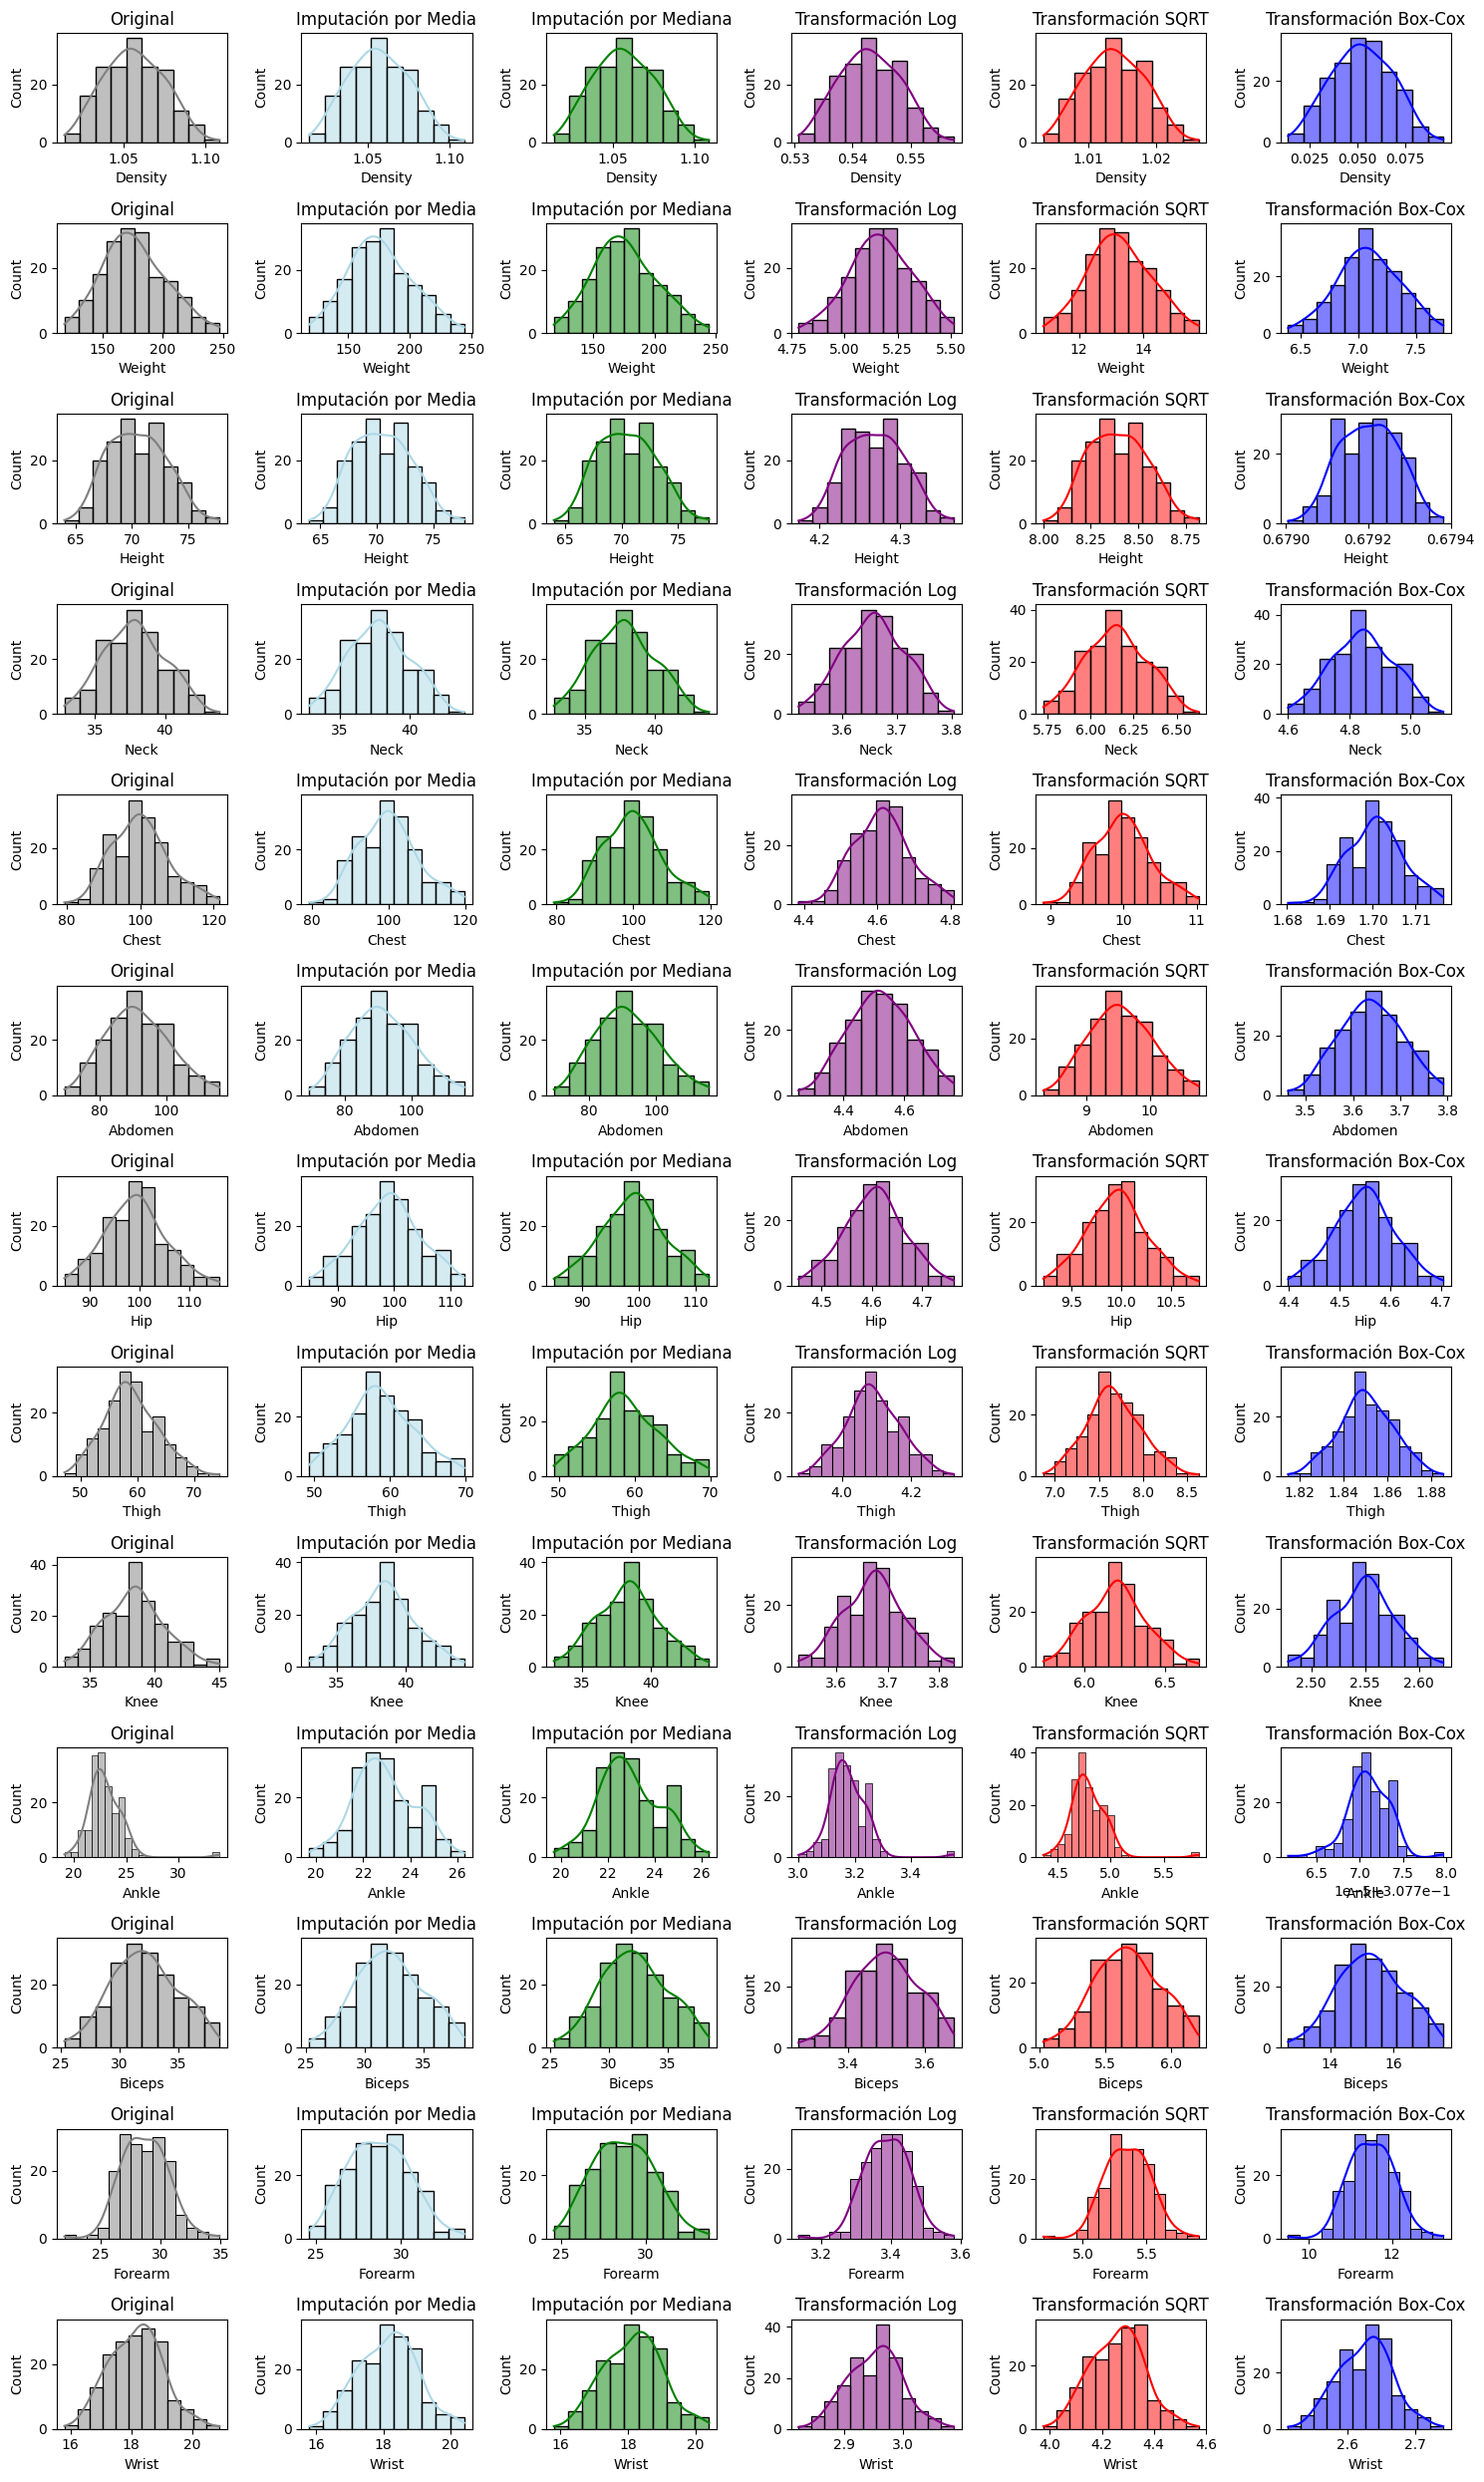

In [117]:
fig, axes = plt.subplots(nrows=13, ncols=6, figsize=(15,25))
colores = ["gray", "lightblue", "green", "purple", "red", "blue"]
titulos = ["Original", "Imputación por Media", "Imputación por Mediana", "Transformación Log", "Transformación SQRT", "Transformación Box-Cox"]

for i, col in enumerate(X_train_mean.columns):
    sns.histplot(X_train[col], kde=True, ax=axes[i, 0], color=colores[0])
    sns.histplot(X_train_mean[col], kde=True, ax=axes[i, 1], color=colores[1])
    sns.histplot(X_train_median[col], kde=True, ax=axes[i, 2], color=colores[2])
    sns.histplot(X_train_log[col], kde=True, ax=axes[i, 3], color=colores[3])
    sns.histplot(X_train_sqrt[col], kde=True, ax=axes[i, 4], color=colores[4])
    sns.histplot(X_train_box_cox[col], kde=True, ax=axes[i, 5], color=colores[5])

    for j in range(6):
        axes[i, j].set_xlabel(col)
        axes[i, j].set_title(titulos[j])

plt.tight_layout()
plt.show()

Básandonos en los gráficos anteriores, podemos notar que las transformaciones de [Boxcox](https://www.geeksforgeeks.org/python/box-cox-transformation-using-python/) no solo ayudan en el tratamiento de outliers, sino que también reducen la asimetría de algunas variables (como `Ankle`) y normalizan su distribución (ejemplos: `Hip` y `Weight`).

In [118]:
# Generamos copias del dataset de train, para no modificar al original
y_train_mean = y_train.copy()
y_train_median = y_train.copy()
y_train_log = y_train.copy()
y_train_sqrt = y_train.copy()
y_train_box_cox = y_train.copy()

# Generamos copias del dataset de test, para no modificar al original
y_test_mean = y_test.copy()
y_test_median = y_test.copy()
y_test_log = y_test.copy()
y_test_sqrt = y_test.copy()
y_test_box_cox = y_test.copy()

Q1 = y_train_mean.quantile(0.25)
Q3 = y_train_mean.quantile(0.75)

# Calculamos el IQR para cada columna (exceptuando Age)
IQR = Q3-Q1
# Definimos el mínimo y máximo para determinar Outliers
min_iqr = Q1 - 1.5*IQR
max_iqr = Q3 + 1.5*IQR

# Identificamos los outliers en train y test
outliers_train = (y_train_mean < min_iqr) | (y_train_mean > max_iqr)
outliers_test = (y_test_mean < min_iqr) | (y_test_mean > max_iqr)


In [119]:
media_col = y_train.mean()
mediana_col = y_train.median()

# Imputación por Media
y_train_mean.loc[outliers_train] = media_col
y_test_mean.loc[outliers_test] = media_col

# Imputación por Mediana
y_train_median.loc[outliers_train] = mediana_col
y_test_median.loc[outliers_test] = media_col

# Transformación logarítmica
y_train_log = np.log1p(y_train_log)
y_test_log = np.log1p(y_test_log)

# Transformación raíz cuadrada
y_train_sqrt = np.sqrt(y_train_sqrt)
y_test_sqrt = np.sqrt(y_test_sqrt)

# Transformación Box-cox
y_train_box_cox, _ = stats.boxcox(y_train_box_cox)
y_test_box_cox, _ = stats.boxcox(y_test_box_cox)

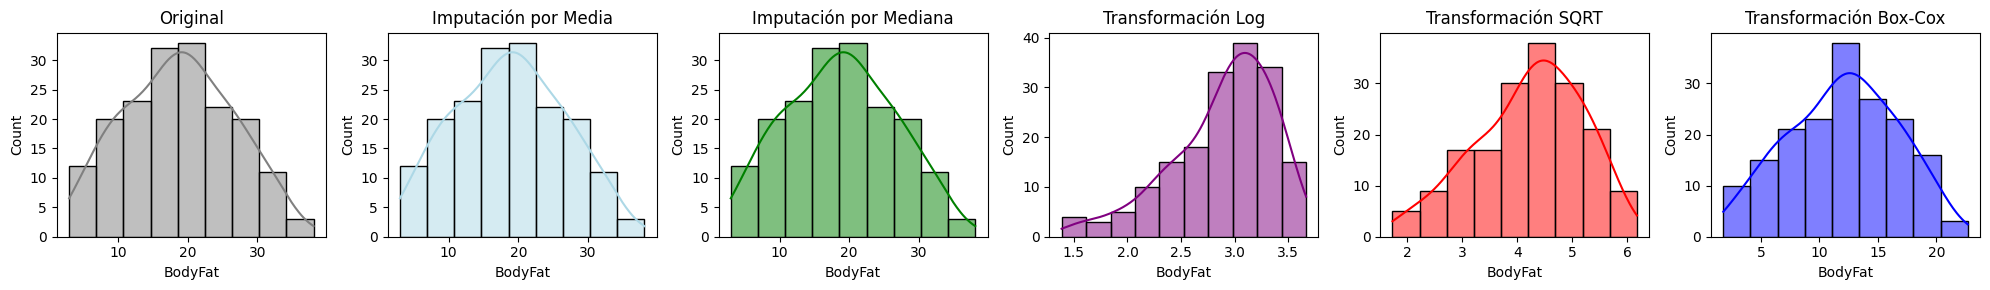

In [127]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20,3))
colores = ["gray", "lightblue", "green", "purple", "red", "blue"]
titulos = ["Original", "Imputación por Media", "Imputación por Mediana", "Transformación Log", "Transformación SQRT", "Transformación Box-Cox"]

sns.histplot(y_train, kde=True, ax=axes[0], color=colores[0])
sns.histplot(y_train_mean, kde=True, ax=axes[1], color=colores[1])
sns.histplot(y_train_median, kde=True, ax=axes[2], color=colores[2])
sns.histplot(y_train_log, kde=True, ax=axes[3], color=colores[3])
sns.histplot(y_train_sqrt, kde=True, ax=axes[4], color=colores[4])
sns.histplot(y_train_box_cox, kde=True, ax=axes[5], color=colores[5])

for j in range(6):
    axes[j].set_xlabel(target)
    axes[j].set_title(titulos[j])

plt.tight_layout()
plt.show()

De manera similar a como sucede en *train*, para la variable `target` (`BodyFat`) la mejor transformación resulta ser la de ***Boxcox***, ya que reduce outliers, ayuda con la asimetría, y normaliza la distribución. En cambio, las transformaciones logarítmicas y por raíz cuadrada tienden a generar una distribución con asimetría a izquierda (más acentuada en el caso de la transformación logarítmica), mediantes que ambas técnicas de imputación tienen una ligera asimetría a derecha.

Para tener un criterio unificado, optamos por tratar los outliers de todas las variables tanto en *train* como en *test* mediante la transformación `Boxcox`.

In [128]:
for col in X_train_box_cox.columns:
    X_train[col] = X_train_box_cox[col]
    X_test[col] = X_test_box_cox[col]

y_train = y_train_box_cox
y_test = y_test_box_cox

In [129]:
# Borramos los datasets extras que se crearon

del X_train_log, X_train_sqrt, X_train_box_cox, X_train_mean, X_train_median, X_test_box_cox, X_test_log, X_test_mean, X_test_median, X_test_sqrt, y_train_box_cox, y_train_log, y_train_sqrt, y_train_mean, y_train_median, y_test_box_cox, y_test_log, y_test_sqrt, y_test_mean, y_test_median

In [ ]:
# Mostramos caaracterísticas generales del nuevo X_train
X_train.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,0.052403,44.562500,7.088997,0.679203,4.843037,1.700612,3.637641,4.548893,1.850257,2.549263,0.307771,15.282957,11.509003,2.626194
std,0.015872,12.588274,0.270455,0.000071,0.099822,0.006467,0.066866,0.059575,0.012498,0.027732,0.000002,1.035458,0.550363,0.039870
min,0.013748,23.000000,6.391299,0.679006,4.600388,1.680234,3.462216,4.399169,1.814630,2.478424,0.307762,12.667472,9.502585,2.512733
25%,0.040163,35.000000,6.913500,0.679148,4.772604,1.695546,3.588411,4.509743,1.842986,2.528926,0.307770,14.525563,11.135245,2.600384
50%,0.052504,43.000000,7.095544,0.679199,4.843792,1.700567,3.636142,4.551083,1.849882,2.550105,0.307771,15.255708,11.490035,2.629016
75%,0.064780,52.250000,7.279583,0.679253,4.915908,1.704639,3.687074,4.582890,1.858232,2.565550,0.307773,15.973263,11.888655,2.655528
max,0.095193,81.000000,7.732162,0.679382,5.106182,1.716431,3.790785,4.704675,1.885483,2.622725,0.307780,17.585919,13.232417,2.741670


In [ ]:
# Mostramos caaracterísticas generales del nuevo X_test
X_test.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,76.000000,76.000000,76.000000,7.600000e+01,76.000000,7.600000e+01,76.000000,7.600000e+01,76.000000,76.000000,7.600000e+01,76.000000,76.000000,76.000000
mean,0.058259,45.631579,1.029607,1.297075e+13,1.363366,3.902873e-01,0.759731,2.463665e-01,0.699730,0.394226,1.949064e-01,2.472932,20773.162926,0.972738
std,0.023924,12.685784,0.001144,3.952836e+12,0.006512,6.245550e-07,0.000325,5.478250e-10,0.000279,0.000006,5.794928e-09,0.051708,5110.569186,0.003322
min,-0.004961,22.000000,1.026774,1.831831e+10,1.344182,3.902858e-01,0.758974,2.463665e-01,0.699097,0.394213,1.949064e-01,2.340966,7289.690858,0.964399
25%,0.042468,38.500000,1.028824,1.028932e+13,1.359573,3.902869e-01,0.759534,2.463665e-01,0.699595,0.394223,1.949064e-01,2.443865,17185.551530,0.970576
50%,0.054995,44.500000,1.029601,1.247511e+13,1.363651,3.902873e-01,0.759717,2.463665e-01,0.699737,0.394227,1.949064e-01,2.468864,21131.979218,0.972947
75%,0.076932,54.000000,1.030355,1.597547e+13,1.367958,3.902877e-01,0.759943,2.463665e-01,0.699890,0.394229,1.949064e-01,2.508833,23846.864644,0.974842
max,0.114543,72.000000,1.033074,2.108531e+13,1.386637,3.902889e-01,0.760633,2.463665e-01,0.700587,0.394243,1.949064e-01,2.627939,35312.997328,0.981376


## Paso 5 - Creación de nuevas features

***TO-DO***: crear algunas features nuevas, por ejemplo, BMI (índice de masa corporal).

## Paso 6 - Discretización de features

***TO-DO***: discretizar alguna feature (ej: BMI según definición de *sobrepeso*, *peso bajo*, etc. Seguramente haya que borrar BMI original)

## Paso 7 - Codificación de features

***TO-DO***: puede ser que no sea necesario. Dependerá si creamos alguna feature categórica en pasos anteriores. Si no hay nada para discretizar, borrar la sección, y reajustar los números de pasos.

## Paso 8 - Escalado de features

***TO-DO***: explorar tanto Normalización como Estandarización. Graficar y comparar.
***NOTA***: seguramente se elija Estandarización, ya que es la más recomendada para Regresión Lineal, ***SVM*** y otros algoritmos que asumen distribuciones normales.

## Paso 9 - Reducción de dimensionalidad

***TO-DO***: PCA vale la pena? O borramos las que tienen correlación alta (como `Density`)?

## Paso 10 - Entrenamiento de Algoritmos

**TO-DO**:

Algoritmos a explorar (***Regresión***):

- Regresión Lineal, Ridge, y Lasso (si los consideran simples, los sacamos de la lista)
- SVM
- Random Forest
- XGBoost para regresión?

Idealmente, para cada uno deberíamos hacer:

- Optimizar hiperparámetros
    - Grid search o Bayesian search? Idealmente, la misma técnica en cada algoritmo, para que la comparación sea adecuada.
- Entrenar y ajustar
- Obtener métricas (podemos usar las mismas que usan en las notebooks de clase de cada algoritmo)
    - Como performan en *test*?

Finalmente, comparar las métricas y sacar conclusiones.